# 04 - Full Mini-NOVIC Decoder Training

## Objective

Notebook 03 verified that the autoregressive decoder architecture is correct by
successfully overfitting a tiny set of 32 examples.

This notebook now trains the same decoder on the complete caption-embedding dataset
created in Notebook 02.

The training pipeline is:

cached CLIP text embedding
→ prefix projection
→ prefix-conditioned autoregressive Transformer
→ noun token sequence
→ EOS

The goals of this notebook are:

1. Load the full cached CLIP text-embedding dataset.
2. Recreate the same noun tokenizer and target sequences used in Notebook 03.
3. Split the cached data into training and validation sets.
4. Train the decoder on all training caption embeddings.
5. Monitor training loss, validation loss, and token accuracy.
6. Save the best validation checkpoint.
7. Reload the best checkpoint.
8. Generate nouns autoregressively for the held-out validation embeddings.
9. Measure exact noun accuracy.
10. Evaluate multi-word noun generation separately.
11. Inspect failure cases.

No embedding noise is added yet.

This notebook establishes the clean no-noise baseline before image substitution
and NOVIC-specific refinements such as embedding noise and beam search.

## 1. Environment setup

In [1]:
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


## 2. Persistent storage paths

The CLIP text embeddings were cached in Notebook 02.

Large checkpoints and experiment outputs are stored in Google Drive so they persist
even when the Colab runtime disconnects.

In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
DRIVE_ROOT = Path(
    "/content/drive/MyDrive/mini_novic_storage"
)

EMBEDDING_CACHE = (
    DRIVE_ROOT
    / "embeddings"
    / "text_embedding_dataset"
    / "clip_text_embeddings.pt"
)

CHECKPOINT_DIR = (
    DRIVE_ROOT
    / "checkpoints"
    / "full_decoder_training"
)

RESULT_DIR = (
    DRIVE_ROOT
    / "results"
    / "full_decoder_training"
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Embedding cache:", EMBEDDING_CACHE)
print("Checkpoint dir :", CHECKPOINT_DIR)
print("Result dir     :", RESULT_DIR)

Embedding cache: /content/drive/MyDrive/mini_novic_storage/embeddings/text_embedding_dataset/clip_text_embeddings.pt
Checkpoint dir : /content/drive/MyDrive/mini_novic_storage/checkpoints/full_decoder_training
Result dir     : /content/drive/MyDrive/mini_novic_storage/results/full_decoder_training


## 3. Load the cached CLIP text embeddings

CLIP is not executed during decoder training.

Each caption has already been converted into an L2-normalized CLIP text embedding.
The decoder therefore trains directly on the cached semantic vectors.

In [5]:
cache = torch.load(
    EMBEDDING_CACHE,
    map_location="cpu"
)

embeddings = cache["embeddings"]
noun_texts = cache["noun_text"]
splits = cache["split"]

print("Embeddings shape:", embeddings.shape)
print("Number of noun labels:", len(noun_texts))
print("CLIP model:", cache["model_name"])
print("Pretrained:", cache["pretrained"])

Embeddings shape: torch.Size([2500, 512])
Number of noun labels: 2500
CLIP model: ViT-B-32
Pretrained: laion2b_s34b_b79k


Check normalization:

In [6]:
norms = embeddings.norm(dim=-1)

print("Minimum norm:", norms.min().item())
print("Maximum norm:", norms.max().item())
print("Mean norm   :", norms.mean().item())

Minimum norm: 0.9999997615814209
Maximum norm: 1.000000238418579
Mean norm   : 1.0


## 4. Recreate the target noun vocabulary

The decoder vocabulary must be identical to Notebook 03.

The current Mini-NOVIC implementation uses a small word-level vocabulary with:

- `<PAD>`
- `<EOS>`
- all words appearing in the controlled object-noun dictionary

The final paper-faithful implementation will later use the tokenizer associated
with the frozen vision-language model.

In [7]:
unique_nouns = sorted(
    set(noun_texts)
)

special_tokens = [
    "<PAD>",
    "<EOS>"
]

words = set()

for noun in unique_nouns:
    for word in noun.split():
        words.add(word)

vocab = (
    special_tokens
    + sorted(words)
)

token_to_id = {
    token: idx
    for idx, token in enumerate(vocab)
}

id_to_token = {
    idx: token
    for token, idx in token_to_id.items()
}

PAD_ID = token_to_id["<PAD>"]
EOS_ID = token_to_id["<EOS>"]

VOCAB_SIZE = len(vocab)

print("Number of nouns:", len(unique_nouns))
print("Vocabulary size:", VOCAB_SIZE)
print("PAD ID:", PAD_ID)
print("EOS ID:", EOS_ID)

Number of nouns: 50
Vocabulary size: 58
PAD ID: 0
EOS ID: 1


# Target encoding functions

In [8]:
def encode_noun(noun):
    token_ids = [
        token_to_id[word]
        for word in noun.split()
    ]

    token_ids.append(EOS_ID)

    return token_ids

In [9]:
def decode_tokens(token_ids):

    words = []

    for token_id in token_ids:

        if token_id == EOS_ID:
            break

        if token_id == PAD_ID:
            continue

        words.append(
            id_to_token[token_id]
        )

    return " ".join(words)

Determine sequence length:

In [10]:
encoded_targets = [
    encode_noun(noun)
    for noun in noun_texts
]

MAX_TARGET_LEN = max(
    len(sequence)
    for sequence in encoded_targets
)

MAX_SEQ_LEN = max(
    MAX_TARGET_LEN,
    4
)

print("Maximum target length:", MAX_TARGET_LEN)
print("Sequence length:", MAX_SEQ_LEN)

Maximum target length: 3
Sequence length: 4


## Pad all target sequences

In [11]:
def pad_sequence(sequence):

    sequence = sequence[
        :MAX_SEQ_LEN
    ]

    padding_needed = (
        MAX_SEQ_LEN
        - len(sequence)
    )

    return (
        sequence
        + [PAD_ID] * padding_needed
    )

In [12]:
target_sequences = torch.tensor(
    [
        pad_sequence(
            encode_noun(noun)
        )
        for noun in noun_texts
    ],
    dtype=torch.long
)

print(
    "Target tensor shape:",
    target_sequences.shape
)

Target tensor shape: torch.Size([2500, 4])


## Verify tokenization before training

In [13]:
for i in range(10):

    print(
        noun_texts[i],
        "→",
        target_sequences[i].tolist(),
        "→",
        decode_tokens(
            target_sequences[i].tolist()
        )
    )

dog → [24, 1, 0, 0] → dog
dog → [24, 1, 0, 0] → dog
dog → [24, 1, 0, 0] → dog
dog → [24, 1, 0, 0] → dog
dog → [24, 1, 0, 0] → dog
dog → [24, 1, 0, 0] → dog
dog → [24, 1, 0, 0] → dog
dog → [24, 1, 0, 0] → dog
dog → [24, 1, 0, 0] → dog
dog → [24, 1, 0, 0] → dog


## 5. Train-validation split

The train/validation split stored in the embedding cache is reused exactly.

No new random split is generated here.

This ensures that Notebook 04 evaluates on the same held-out caption embeddings
created in Notebook 02.

In [14]:
train_mask = torch.tensor(
    [
        split == "train"
        for split in splits
    ],
    dtype=torch.bool
)

val_mask = torch.tensor(
    [
        split == "val"
        for split in splits
    ],
    dtype=torch.bool
)

In [15]:
X_train = embeddings[
    train_mask
]

y_train = target_sequences[
    train_mask
]

X_val = embeddings[
    val_mask
]

y_val = target_sequences[
    val_mask
]

train_nouns = [
    noun
    for noun, split in zip(
        noun_texts,
        splits
    )
    if split == "train"
]

val_nouns = [
    noun
    for noun, split in zip(
        noun_texts,
        splits
    )
    if split == "val"
]

print("Training embeddings :", X_train.shape)
print("Training targets    :", y_train.shape)

print("Validation embeddings:", X_val.shape)
print("Validation targets   :", y_val.shape)

Training embeddings : torch.Size([2000, 512])
Training targets    : torch.Size([2000, 4])
Validation embeddings: torch.Size([500, 512])
Validation targets   : torch.Size([500, 4])


## 6. DataLoaders

The cached embeddings are already small tensors, so training does not require CLIP
or image preprocessing.

DataLoaders are used to create shuffled training mini-batches and deterministic
validation mini-batches.

In [16]:
BATCH_SIZE = 64

train_dataset = TensorDataset(
    X_train,
    y_train
)

val_dataset = TensorDataset(
    X_val,
    y_val
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False
)

print(
    "Training batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

Training batches: 32
Validation batches: 4


# Recreate the attention mask

Use the same function as Notebook 03.

In [17]:
def build_attention_mask(
    prefix_len,
    token_len,
    device
):

    total_len = (
        prefix_len
        + token_len
    )

    mask = torch.full(
        (total_len, total_len),
        float("-inf"),
        device=device
    )

    # Prefix tokens attend freely
    # to all prefix tokens.
    mask[
        :prefix_len,
        :prefix_len
    ] = 0

    # Generated token positions attend
    # to all prefixes and only previous/
    # current token positions.
    for i in range(token_len):

        row = prefix_len + i

        mask[
            row,
            :prefix_len + i + 1
        ] = 0

    return mask

# Recreate the exact working decoder

Important: use the same modified decoder from Notebook 03.

In [18]:
class MiniNOVICDecoder(nn.Module):

    def __init__(
        self,
        clip_dim,
        vocab_size,
        hidden_dim=256,
        prefix_len=4,
        max_seq_len=4,
        num_layers=4,
        num_heads=4,
        dropout=0.1,
    ):

        super().__init__()

        self.hidden_dim = hidden_dim
        self.prefix_len = prefix_len
        self.max_seq_len = max_seq_len

        # ----------------------------------
        # CLIP embedding -> prefix vectors
        # ----------------------------------

        self.prefix_mapper = nn.Linear(
            clip_dim,
            prefix_len * hidden_dim
        )

        # ----------------------------------
        # Learned noun-token embeddings
        # ----------------------------------

        self.token_embedding = nn.Embedding(
            vocab_size,
            hidden_dim
        )

        # ----------------------------------
        # Learned positional embeddings
        # ----------------------------------

        self.position_embedding = nn.Embedding(
            prefix_len + max_seq_len,
            hidden_dim
        )

        # ----------------------------------
        # Decoder-only Transformer stack
        # ----------------------------------

        transformer_layer = (
            nn.TransformerEncoderLayer(
                d_model=hidden_dim,
                nhead=num_heads,
                dim_feedforward=hidden_dim * 4,
                dropout=dropout,
                activation="gelu",
                batch_first=True,
                norm_first=True,
            )
        )

        self.transformer = (
            nn.TransformerEncoder(
                transformer_layer,
                num_layers=num_layers
            )
        )

        # ----------------------------------
        # Hidden states -> vocabulary logits
        # ----------------------------------

        self.output_projection = nn.Linear(
            hidden_dim,
            vocab_size
        )

    def forward(
        self,
        clip_embeddings,
        token_ids
    ):

        batch_size = (
            clip_embeddings.size(0)
        )

        # ----------------------------------
        # 1. CLIP embedding -> prefix
        # ----------------------------------

        prefix = self.prefix_mapper(
            clip_embeddings
        )

        prefix = prefix.view(
            batch_size,
            self.prefix_len,
            self.hidden_dim
        )

        # ----------------------------------
        # 2. Token IDs -> token embeddings
        # ----------------------------------

        token_vectors = (
            self.token_embedding(
                token_ids
            )
        )

        # ----------------------------------
        # 3. Prefix + token vectors
        # ----------------------------------

        x = torch.cat(
            [
                prefix,
                token_vectors
            ],
            dim=1
        )

        total_len = x.size(1)

        # ----------------------------------
        # 4. Add learned positions
        # ----------------------------------

        positions = torch.arange(
            total_len,
            device=x.device
        )

        x = (
            x
            + self.position_embedding(
                positions
            ).unsqueeze(0)
        )

        # ----------------------------------
        # 5. Prefix + causal attention mask
        # ----------------------------------

        mask = build_attention_mask(
            self.prefix_len,
            token_ids.size(1),
            x.device
        )

        # ----------------------------------
        # 6. Transformer
        # ----------------------------------

        x = self.transformer(
            x,
            mask=mask
        )

        # ----------------------------------
        # 7. Shifted prediction positions
        #
        # Last prefix -> target token 1
        # T1          -> target token 2
        # T2          -> target token 3
        # ...
        # ----------------------------------

        prediction_states = x[
            :,
            self.prefix_len - 1:,
            :
        ]

        logits = self.output_projection(
            prediction_states
        )

        return logits

## 7. Decoder configuration

The same small architecture validated in Notebook 03 is retained.

Changing the architecture at this point would make it difficult to determine
whether training problems come from the dataset or from new model changes.

In [19]:
CLIP_DIM = embeddings.shape[1]

PREFIX_LEN = 4
HIDDEN_DIM = 256

NUM_LAYERS = 4
NUM_HEADS = 4

DROPOUT = 0.1

In [20]:
decoder = MiniNOVICDecoder(
    clip_dim=CLIP_DIM,
    vocab_size=VOCAB_SIZE,
    hidden_dim=HIDDEN_DIM,
    prefix_len=PREFIX_LEN,
    max_seq_len=MAX_SEQ_LEN,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
    dropout=DROPOUT,
).to(device)

/tmp/ipykernel_725/180936462.py:65: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  nn.TransformerEncoder(


Count parameters:

In [21]:
num_parameters = sum(
    p.numel()
    for p in decoder.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in decoder.parameters()
    if p.requires_grad
)

print(
    f"Total parameters: "
    f"{num_parameters:,}"
)

print(
    f"Trainable parameters: "
    f"{trainable_parameters:,}"
)

Total parameters: 3,716,154
Trainable parameters: 3,716,154


# Loss function
Use the same corrected loss.

In [22]:
criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_ID
)

In [23]:
def compute_decoder_loss(
    model,
    clip_embeddings,
    target_tokens,
    criterion
):

    # Remove final target token.
    # Prefix predicts target token 1.
    token_inputs = (
        target_tokens[:, :-1]
    )

    # Model already returns shifted logits.
    logits = model(
        clip_embeddings,
        token_inputs
    )

    assert (
        logits.shape[:2]
        ==
        target_tokens.shape
    ), (
        f"Shape mismatch: "
        f"logits={logits.shape}, "
        f"targets={target_tokens.shape}"
    )

    loss = criterion(
        logits.reshape(
            -1,
            logits.size(-1)
        ),
        target_tokens.reshape(-1)
    )

    return loss, logits

## Token accuracy function

In [24]:
def token_accuracy(
    logits,
    targets
):

    predictions = logits.argmax(
        dim=-1
    )

    valid_mask = (
        targets != PAD_ID
    )

    correct = (
        predictions == targets
    ) & valid_mask

    return (
        correct.sum().float()
        /
        valid_mask.sum().float()
    ).item()

## 8. Validation function

Validation uses teacher forcing only for measuring validation loss and token accuracy.

Later, exact noun accuracy will be measured separately using genuine autoregressive
greedy generation.

In [25]:
@torch.no_grad()
def evaluate_teacher_forced(
    model,
    loader,
    criterion
):

    model.eval()

    total_loss = 0.0

    total_correct = 0
    total_valid = 0

    for batch_X, batch_y in loader:

        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        loss, logits = (
            compute_decoder_loss(
                model,
                batch_X,
                batch_y,
                criterion
            )
        )

        total_loss += (
            loss.item()
            * batch_X.size(0)
        )

        predictions = logits.argmax(
            dim=-1
        )

        valid_mask = (
            batch_y != PAD_ID
        )

        correct = (
            predictions == batch_y
        ) & valid_mask

        total_correct += (
            correct.sum().item()
        )

        total_valid += (
            valid_mask.sum().item()
        )

    average_loss = (
        total_loss
        / len(loader.dataset)
    )

    token_acc = (
        total_correct
        / total_valid
    )

    return (
        average_loss,
        token_acc
    )

## 9. Full decoder training

The full dataset is trained using AdamW.

This experiment intentionally uses no embedding noise so that it serves as the
clean baseline for later NOVIC-specific noise ablations.

In [26]:
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
NUM_EPOCHS = 30

optimizer = torch.optim.AdamW(
    decoder.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Best-checkpoint path

In [27]:
BEST_CHECKPOINT = (
    CHECKPOINT_DIR
    / "best_full_decoder.pt"
)

print(
    "Best checkpoint path:",
    BEST_CHECKPOINT
)

Best checkpoint path: /content/drive/MyDrive/mini_novic_storage/checkpoints/full_decoder_training/best_full_decoder.pt


# Full training loop

In [28]:
history = []

best_val_loss = float("inf")

for epoch in range(
    1,
    NUM_EPOCHS + 1
):

    # ==================================
    # Training
    # ==================================

    decoder.train()

    total_train_loss = 0.0
    total_train_correct = 0
    total_train_valid = 0

    for batch_X, batch_y in train_loader:

        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        loss, logits = (
            compute_decoder_loss(
                decoder,
                batch_X,
                batch_y,
                criterion
            )
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            decoder.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_train_loss += (
            loss.item()
            * batch_X.size(0)
        )

        predictions = logits.argmax(
            dim=-1
        )

        valid_mask = (
            batch_y != PAD_ID
        )

        correct = (
            predictions == batch_y
        ) & valid_mask

        total_train_correct += (
            correct.sum().item()
        )

        total_train_valid += (
            valid_mask.sum().item()
        )

    train_loss = (
        total_train_loss
        / len(train_dataset)
    )

    train_token_acc = (
        total_train_correct
        / total_train_valid
    )

    # ==================================
    # Validation
    # ==================================

    val_loss, val_token_acc = (
        evaluate_teacher_forced(
            decoder,
            val_loader,
            criterion
        )
    )

    # ==================================
    # Save best model
    # ==================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            {
                "model_state_dict":
                    decoder.state_dict(),

                "epoch":
                    epoch,

                "val_loss":
                    val_loss,

                "clip_dim":
                    CLIP_DIM,

                "hidden_dim":
                    HIDDEN_DIM,

                "prefix_len":
                    PREFIX_LEN,

                "num_layers":
                    NUM_LAYERS,

                "num_heads":
                    NUM_HEADS,

                "max_seq_len":
                    MAX_SEQ_LEN,

                "vocab":
                    vocab,

                "token_to_id":
                    token_to_id,

                "id_to_token":
                    id_to_token,

                "pad_id":
                    PAD_ID,

                "eos_id":
                    EOS_ID,

                "seed":
                    SEED,
            },
            BEST_CHECKPOINT
        )

        checkpoint_marker = " ← best"

    else:

        checkpoint_marker = ""

    # ==================================
    # Save history
    # ==================================

    history.append({
        "epoch":
            epoch,

        "train_loss":
            train_loss,

        "train_token_accuracy":
            train_token_acc,

        "val_loss":
            val_loss,

        "val_token_accuracy":
            val_token_acc,
    })

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Tok Acc: "
        f"{train_token_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Tok Acc: "
        f"{val_token_acc*100:.2f}%"
        f"{checkpoint_marker}"
    )

Epoch 01/30 | Train Loss: 2.1939 | Train Tok Acc: 50.23% | Val Loss: 1.8030 | Val Tok Acc: 58.92% ← best
Epoch 02/30 | Train Loss: 1.7189 | Train Tok Acc: 57.70% | Val Loss: 1.6574 | Val Tok Acc: 59.28% ← best
Epoch 03/30 | Train Loss: 1.3856 | Train Tok Acc: 66.91% | Val Loss: 0.8562 | Val Tok Acc: 80.54% ← best
Epoch 04/30 | Train Loss: 0.5451 | Train Tok Acc: 87.14% | Val Loss: 0.2217 | Val Tok Acc: 97.57% ← best
Epoch 05/30 | Train Loss: 0.1438 | Train Tok Acc: 97.61% | Val Loss: 0.1520 | Val Tok Acc: 96.22% ← best
Epoch 06/30 | Train Loss: 0.0496 | Train Tok Acc: 99.03% | Val Loss: 0.0273 | Val Tok Acc: 99.19% ← best
Epoch 07/30 | Train Loss: 0.0202 | Train Tok Acc: 99.68% | Val Loss: 0.0227 | Val Tok Acc: 99.28% ← best
Epoch 08/30 | Train Loss: 0.0110 | Train Tok Acc: 99.86% | Val Loss: 0.0056 | Val Tok Acc: 99.91% ← best
Epoch 09/30 | Train Loss: 0.0024 | Train Tok Acc: 100.00% | Val Loss: 0.0004 | Val Tok Acc: 100.00% ← best
Epoch 10/30 | Train Loss: 0.0006 | Train Tok Acc: 100

## Inspect training history

In [29]:
history_df = pd.DataFrame(
    history
)

display(history_df)

,epoch,train_loss,train_token_accuracy,val_loss,val_token_accuracy
0,1,2.193906,0.502252,1.803011,0.589189
1,2,1.718868,0.577027,1.657375,0.592793
2,3,1.385631,0.669144,0.856169,0.805405
3,4,0.545121,0.871396,0.221724,0.975676
4,5,0.143846,0.976126,0.152035,0.962162
5,6,0.049587,0.990315,0.027254,0.991892
6,7,0.020190,0.996847,0.022738,0.992793
7,8,0.011045,0.998649,0.005557,0.999099
8,9,0.002361,1.000000,0.000369,1.000000
9,10,0.000623,1.000000,0.000253,1.000000


Save it:

In [30]:
history_df.to_csv(
    RESULT_DIR
    / "training_history.csv",
    index=False
)

## Plot training and validation loss

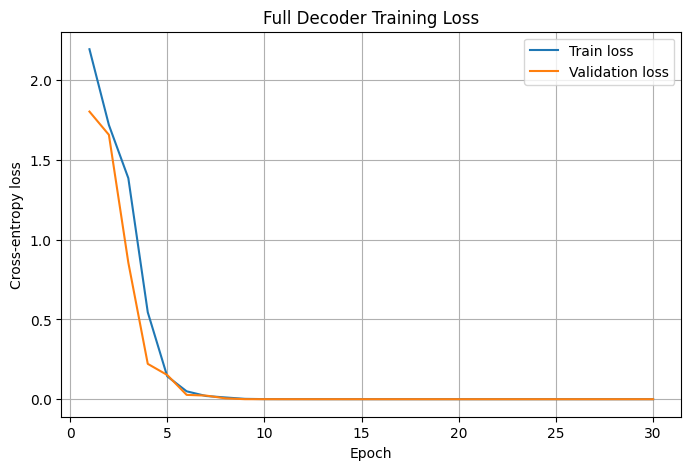

In [31]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")

plt.title(
    "Full Decoder Training Loss"
)

plt.legend()
plt.grid(True)

plt.show()

## Plot token accuracy

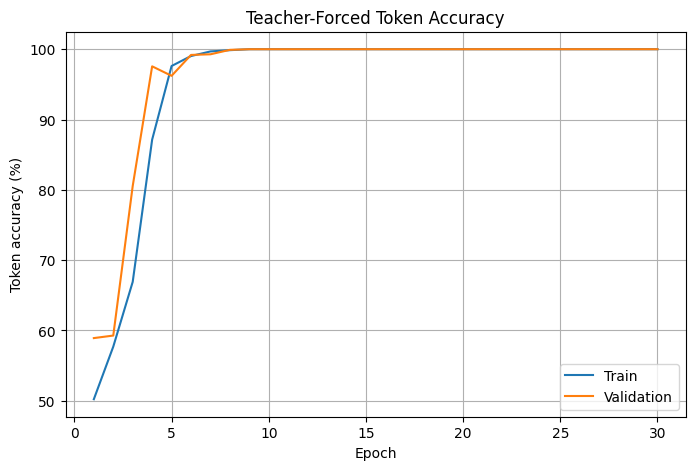

In [32]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history_df["epoch"],
    history_df[
        "train_token_accuracy"
    ] * 100,
    label="Train"
)

plt.plot(
    history_df["epoch"],
    history_df[
        "val_token_accuracy"
    ] * 100,
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Token accuracy (%)")

plt.title(
    "Teacher-Forced Token Accuracy"
)

plt.legend()
plt.grid(True)

plt.show()

# Load the best checkpoint

In [33]:
checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location=device
)

decoder.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

decoder.eval()

print(
    "Loaded checkpoint from epoch:",
    checkpoint["epoch"]
)

print(
    "Best validation loss:",
    checkpoint["val_loss"]
)

Loaded checkpoint from epoch: 29
Best validation loss: 3.053483774419874e-05


# Greedy generation function
Use the same version that worked in Notebook 03.

In [34]:
@torch.no_grad()
def generate_greedy(
    model,
    clip_embedding,
    max_length=MAX_SEQ_LEN
):

    model.eval()

    if clip_embedding.dim() == 1:

        clip_embedding = (
            clip_embedding.unsqueeze(0)
        )

    clip_embedding = (
        clip_embedding.to(device)
    )

    generated = []

    for _ in range(max_length):

        if len(generated) == 0:

            token_inputs = torch.empty(
                (1, 0),
                dtype=torch.long,
                device=device
            )

        else:

            token_inputs = torch.tensor(
                [generated],
                dtype=torch.long,
                device=device
            )

        logits = model(
            clip_embedding,
            token_inputs
        )

        next_logits = logits[
            :,
            -1,
            :
        ]

        next_token = (
            next_logits
            .argmax(dim=-1)
            .item()
        )

        if next_token == EOS_ID:
            break

        if next_token == PAD_ID:
            break

        generated.append(
            next_token
        )

    return generated

## 10. Autoregressive validation generation

Teacher-forced token accuracy does not prove that the model can generate nouns
by itself.

The decoder is therefore evaluated using greedy autoregressive generation on
held-out validation embeddings.

In [35]:
for i in range(20):

    generated_ids = (
        generate_greedy(
            decoder,
            X_val[i]
        )
    )

    generated_noun = (
        decode_tokens(
            generated_ids
        )
    )

    print(
        f"Expected: "
        f"{val_nouns[i]:20s} | "
        f"Generated: "
        f"{generated_noun}"
    )

Expected: dog                  | Generated: dog
Expected: dog                  | Generated: dog
Expected: dog                  | Generated: dog
Expected: dog                  | Generated: dog
Expected: dog                  | Generated: dog
Expected: dog                  | Generated: dog
Expected: dog                  | Generated: dog
Expected: dog                  | Generated: dog
Expected: dog                  | Generated: dog
Expected: dog                  | Generated: dog
Expected: cat                  | Generated: cat
Expected: cat                  | Generated: cat
Expected: cat                  | Generated: cat
Expected: cat                  | Generated: cat
Expected: cat                  | Generated: cat
Expected: cat                  | Generated: cat
Expected: cat                  | Generated: cat
Expected: cat                  | Generated: cat
Expected: cat                  | Generated: cat
Expected: cat                  | Generated: cat


# Generate predictions for all validation examples

In [36]:
val_predictions = []

for i in range(
    len(X_val)
):

    generated_ids = (
        generate_greedy(
            decoder,
            X_val[i]
        )
    )

    generated_noun = (
        decode_tokens(
            generated_ids
        )
    )

    val_predictions.append(
        generated_noun
    )

## Build validation results table

In [37]:
val_results = pd.DataFrame({
    "expected":
        val_nouns,

    "generated":
        val_predictions
})

val_results[
    "correct"
] = (
    val_results["expected"]
    ==
    val_results["generated"]
)

display(
    val_results.head(30)
)

,expected,generated,correct
0,dog,dog,True
1,dog,dog,True
2,dog,dog,True
3,dog,dog,True
4,dog,dog,True
5,dog,dog,True
6,dog,dog,True
7,dog,dog,True
8,dog,dog,True
9,dog,dog,True


## Exact noun accuracy

In [38]:
exact_accuracy = (
    val_results[
        "correct"
    ].mean()
)

print(
    f"Validation exact noun accuracy: "
    f"{exact_accuracy * 100:.2f}%"
)

Validation exact noun accuracy: 100.00%


## Multi-word noun accuracy

In [39]:
multiword_results = (
    val_results[
        val_results[
            "expected"
        ].str.contains(" ")
    ]
)

print(
    "Number of multi-word validation examples:",
    len(multiword_results)
)

if len(multiword_results) > 0:

    multiword_accuracy = (
        multiword_results[
            "correct"
        ].mean()
    )

    print(
        f"Multi-word exact accuracy: "
        f"{multiword_accuracy * 100:.2f}%"
    )

    display(
        multiword_results.head(30)
    )

Number of multi-word validation examples: 110
Multi-word exact accuracy: 100.00%


,expected,generated,correct
190,sports car,sports car,True
191,sports car,sports car,True
192,sports car,sports car,True
193,sports car,sports car,True
194,sports car,sports car,True
195,sports car,sports car,True
196,sports car,sports car,True
197,sports car,sports car,True
198,sports car,sports car,True
199,sports car,sports car,True


## Single-word accuracy

In [40]:
singleword_results = (
    val_results[
        ~val_results[
            "expected"
        ].str.contains(" ")
    ]
)

singleword_accuracy = (
    singleword_results[
        "correct"
    ].mean()
)

print(
    f"Single-word exact accuracy: "
    f"{singleword_accuracy * 100:.2f}%"
)

Single-word exact accuracy: 100.00%


## 11. Failure analysis

Incorrect predictions are inspected manually.

Special attention is given to semantically related categories such as:

- car vs sports car
- truck vs fire truck
- cup vs coffee mug
- chair vs office chair
- table vs dining table

Such errors may indicate that CLIP embeddings preserve strong semantic similarity
between related concepts.

In [41]:
failures = (
    val_results[
        ~val_results[
            "correct"
        ]
    ]
)

print(
    "Number of validation failures:",
    len(failures)
)

display(
    failures.head(50)
)

Number of validation failures: 0


,expected,generated,correct


In [42]:
if len(failures) > 0:

    confusion_pairs = (
        failures
        .groupby(
            [
                "expected",
                "generated"
            ]
        )
        .size()
        .reset_index(
            name="count"
        )
        .sort_values(
            "count",
            ascending=False
        )
    )

    display(
        confusion_pairs.head(30)
    )

## Per-noun accuracy

In [43]:
per_noun_accuracy = (
    val_results
    .groupby(
        "expected"
    )["correct"]
    .agg(
        [
            "mean",
            "count"
        ]
    )
    .reset_index()
)

per_noun_accuracy[
    "accuracy_percent"
] = (
    per_noun_accuracy[
        "mean"
    ] * 100
)

per_noun_accuracy = (
    per_noun_accuracy
    .sort_values(
        "accuracy_percent"
    )
)

display(
    per_noun_accuracy
)

,expected,mean,count,accuracy_percent
0,airplane,1.0,10,100.0
1,backpack,1.0,10,100.0
2,baseball bat,1.0,10,100.0
3,bear,1.0,10,100.0
4,bed,1.0,10,100.0
5,bicycle,1.0,10,100.0
6,bird,1.0,10,100.0
7,boat,1.0,10,100.0
8,book,1.0,10,100.0
9,bottle,1.0,10,100.0


# Save validation results

In [44]:
val_results.to_csv(
    RESULT_DIR
    / "validation_predictions.csv",
    index=False
)

In [45]:
per_noun_accuracy.to_csv(
    RESULT_DIR
    / "per_noun_accuracy.csv",
    index=False
)

In [46]:
if len(failures) > 0:

    confusion_pairs.to_csv(
        RESULT_DIR
        / "confusion_pairs.csv",
        index=False
    )

# Save final summary metrics

In [47]:
summary = {
    "best_epoch":
        checkpoint["epoch"],

    "best_val_loss":
        checkpoint["val_loss"],

    "exact_noun_accuracy":
        exact_accuracy,

    "singleword_accuracy":
        singleword_accuracy,

    "num_validation_examples":
        len(val_results),
}

if len(multiword_results) > 0:

    summary[
        "multiword_accuracy"
    ] = multiword_accuracy

In [48]:
summary_df = pd.DataFrame(
    [summary]
)

display(summary_df)

,best_epoch,best_val_loss,exact_noun_accuracy,singleword_accuracy,num_validation_examples,multiword_accuracy
0,29,0.000031,1.0,1.0,500,1.0


In [49]:
summary_df.to_csv(
    RESULT_DIR
    / "summary_metrics.csv",
    index=False
)

# Conclusions

Notebook 04 trained the Mini-NOVIC autoregressive decoder on the complete cached
CLIP text-embedding dataset.

The decoder was trained using:

cached CLIP text embedding
→ prefix projection
→ prefix-conditioned Transformer
→ autoregressive noun tokens
→ EOS

The same architecture that passed the tiny-batch overfitting test in Notebook 03
was used without modification.

## Evaluation

The model was evaluated in two different ways:

1. Teacher-forced token accuracy
2. True autoregressive greedy noun generation

Autoregressive exact-match accuracy is the more important metric because it tests
whether the decoder can generate the complete object noun without being given the
correct previous tokens.

Single-word and multi-word object nouns were evaluated separately.

Failure cases were also inspected to identify semantic confusions between related
object categories.

## Current Mini-NOVIC pipeline

The project has now demonstrated:

caption
→ frozen CLIP text encoder
→ normalized text embedding
→ prefix projection
→ autoregressive Transformer
→ generated object noun

The decoder has therefore learned to generate noun strings from held-out CLIP
text embeddings.

## Next stage

The next experiment will perform the central NOVIC-style zero-shot transfer:

image
→ frozen CLIP image encoder
→ normalized image embedding
→ SAME trained prefix mapper and decoder
→ generated object noun

The decoder will not be retrained using image labels.

This will test whether a decoder trained only on text-derived CLIP embeddings can
generalize to image-derived CLIP embeddings through the shared embedding space.